# Module : Artificial Intelligence part 01
### Name : Yatin
<span style="color:#555;font-size:13px;">Lecturer: Prof. Dr. Florian Haselbeck · Professorship Smart Farming · Hochschule Weihenstephan-Triesdorf</span>

---

## Introduction

This notebook presents the complete machine learning workflow for the **SoilNutrientStatus** binary classification task, developed by ExamGroup9.

### Problem Statement
The **SoilNutrientStatus** dataset describes soil properties and management factors of agricultural land. The aim is to predict whether the nutrient status of a field is **Sufficient** or **Insufficient** based on 12 input features (pH, OrganicMatter, Nitrogen, Phosphorus, Potassium, CEC, SoilMoisture, SoilType, Region, CropType, IrrigationLevel, FertilizerUse).

### Type of Machine Learning Task
This is a **Supervised Learning — Binary Classification** task:
- We have **labelled training data** $(\mathbf{x}_n, y_n)$, $n = 1 \ldots N$
- The target $y_n \in \{\text{Sufficient}, \text{Insufficient}\}$ is **discrete** (two categories)
- We are **not** doing unsupervised learning (no labels) or reinforcement learning (no reward signal)

### ML Workflow Overview
Following the standard workflow from the course:
1. Data Exploration
2. Data Split (**before** pre-processing — prevents information leakage)
3. Pre-processing + Feature Engineering (inside CV loop)
4. Hyperparameter optimisation of multiple models (KNN, Logistic Regression, SVM, Random Forest, XGBoost)
5. Model Comparison and Selection (same CV folds for all — fair comparison)
6. Final Model Retraining and Evaluation
7. Leaderboard Prediction

### Strategy for High Leaderboard Performance
- **5-fold StratifiedKFold CV** — more stable than single train-val split
- **Feature engineering** — 5 domain-informed features capturing soil chemistry interactions
- **Wide hyperparameter search spaces** — using both Grid Search and Random Search
- **Train on all 3,000 samples** for the final leaderboard model (leaderboard = external test)
  

---

## References

All code adapted from course exercise notebooks by **Prof. Dr. Florian Haselbeck, AI1, HSWT, 2026:**
- Exercise 3: Data Exploration · Exercise 4: Pre-processing · Exercise 5: Feature Engineering
- Exercise 6: KNN Classification · Exercise 7: KNN with CV · Exercise 8: Logistic Regression
- Exercise 9: SVM · Exercise 10: Random Forest & XGBoost · Exercise 11: Model Comparison

**Libraries:** scikit-learn (https://scikit-learn.org) · xgboost (https://xgboost.readthedocs.io) · pandas · numpy · matplotlib · seaborn

**Dataset:** SoilNutrientStatus, provided by Prof. Dr. Florian Haselbeck, HSWT, AI1 Group Project 2026.

---
## Import Libraries

All required libraries imported at the start for clarity.
- **numpy / pandas** — numerical computation and data handling
- **matplotlib / seaborn** — visualisation
- **sklearn** — all ML models, preprocessing tools, metrics, splitting methods
- **xgboost** — XGBoost ensemble model (separate library, as used in Exercise 10)
- **scipy.stats** — probability distributions for Random Search

In [1]:
# Import the required libraries
# Adapted from: AI1 Exercise Notebooks (Prof. Dr. Florian Haselbeck, HSWT, 2026)

# Matrix and vector calculus
import numpy as np
# Data record editing
import pandas as pd
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning from sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
    KFold, ParameterGrid, ParameterSampler)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
    matthews_corrcoef, accuracy_score, f1_score,
    precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
# XGBoost — separate library (Exercise 10)
from xgboost import XGBClassifier, plot_importance
# Random search distributions
from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---
# Part 1 — Data Exploration
*Responsible: Bardan Neupane*

---

## Theory: Why Data Exploration?

Data exploration is the **first step** in every ML project — we must understand the data before modelling. It answers:
- **What does the data look like?** → `df.head()`, `df.info()`
- **What are the statistics?** → `df.describe()`
- **Are there missing values?** → `df.isnull().sum()`
- **How are features distributed?** → histograms, box plots
- **Are classes balanced?** → `value_counts()`
- **How do features relate?** → correlation heatmap, pairplot

This step **guides all preprocessing decisions** — what to impute, what to encode, what to scale.

**Reference:** Adapted from AI1 Exercise 3 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [2]:
# Loading dataset using the Pandas library
# Adapted from: AI1 Exercise 3 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
df = pd.read_csv('SoilNutrientStatus_knowndata.csv')
print('Dataset loaded!')
print('Shape:', df.shape)

Dataset loaded!
Shape: (3000, 13)


In [3]:
# Display first lines of the data
df.head()

,pH,OrganicMatter,Nitrogen,Phosphorus,Potassium,CEC,SoilMoisture,SoilType,Region,CropType,IrrigationLevel,FertilizerUse,SoilStatus
0,6.415539,1.793552,98.462837,17.208611,226.546223,7.069507,29.163189,Sand,South,Rape,Low,Moderate,Sufficient
1,4.904873,2.702102,77.356975,17.202503,239.086633,13.047803,29.542086,Loam,East,Maize,Medium,Intensive,Sufficient
2,7.601249,3.557328,46.381848,8.427096,220.532597,15.854220,44.616512,Loam,West,Maize,Low,Intensive,Insufficient
3,6.082576,3.946084,58.876094,28.163798,227.901621,18.078626,22.000723,Loam,West,Wheat,Medium,NaN,Insufficient
4,6.077266,4.004932,50.513145,20.538774,175.257552,6.519902,25.871773,Sand,South,Rape,Low,Moderate,Insufficient


In [4]:
# Information about columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pH               2979 non-null   float64
 1   OrganicMatter    2977 non-null   float64
 2   Nitrogen         2978 non-null   float64
 3   Phosphorus       2977 non-null   float64
 4   Potassium        2980 non-null   float64
 5   CEC              2978 non-null   float64
 6   SoilMoisture     2979 non-null   float64
 7   SoilType         2977 non-null   object 
 8   Region           2977 non-null   object 
 9   CropType         2980 non-null   object 
 10  IrrigationLevel  2977 non-null   object 
 11  FertilizerUse    1937 non-null   object 
 12  SoilStatus       3000 non-null   object 
dtypes: float64(7), object(6)
memory usage: 304.8+ KB


**Observation:** 3,000 rows and 13 columns. Numerical features are `float64`. Categorical features (`SoilType`, `Region`, `CropType`, `IrrigationLevel`, `FertilizerUse`) are `object`. Target `SoilStatus` is binary text — will need encoding before some models.

In [5]:
# Get the most important statistical indicators for the numerical columns
df.describe()

,pH,OrganicMatter,Nitrogen,Phosphorus,Potassium,CEC,SoilMoisture
count,2979.000000,2977.000000,2978.000000,2977.000000,2980.000000,2978.000000,2979.000000
mean,6.509594,3.973939,69.781595,21.934655,171.864033,14.000269,25.326632
std,0.588701,1.498965,24.768442,9.702772,59.821615,5.795933,9.616526
min,4.500000,0.500000,5.000000,3.000000,40.000000,3.000000,5.000000
25%,6.106070,2.948807,52.808697,15.102382,131.451741,9.926375,18.679848
50%,6.526869,3.949985,70.007767,21.899804,171.238730,13.843658,25.191391
75%,6.910699,4.947649,86.450364,28.683417,211.503936,17.915167,31.787693
max,8.253290,9.469607,156.584959,53.853485,416.181229,35.578785,55.000000


### 1.1 Missing Values Analysis

## Theory: Why Check Missing Values?

Before any modelling, we must identify and handle missing values. ML models cannot handle NaN values directly — they must be either removed or imputed.

**Decision rules (applied in this order):**

1. **Missing target label** → delete that sample immediately — we cannot train without knowing the true class
2. **Column with >50% missing** → consider column deletion — too little real information to impute reliably
3. **Row with >50% missing** → delete that row — imputing more than half a row means guessing more than half the features, which introduces artificial patterns
4. **Remaining isolated missing values** → impute **after splitting** to avoid information leakage

**Why the 50% threshold for rows?**
Our dataset has 13 columns. More than 6.5 columns missing per row means we would be imputing 7+ features from column statistics alone — the resulting sample would be more statistical fiction than real measurement. Removing these rows is safer than keeping unreliable samples.

**Why impute after splitting?**
If we compute the column mean using ALL data (including test samples) and then use that mean to fill training missing values, the model indirectly sees test data statistics during training. This is called **information leakage** and leads to overly optimistic performance estimates.

**Reference:** Adapted from AI1 Exercise 3 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [6]:
# Check how many missing values there are
# Adapted from: AI1 Exercise 3 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

# Output total number of columns and rows
print('\nNumber of columns (= features + target variable): ')
print(df.shape[1])
print('\nNumber of rows (= samples): ')
print(df.shape[0])

# Check whether all labels are present
print('\nNumber of missing values in the target variable:')
print(df['SoilStatus'].isnull().sum())

# Number of missing values per column
print('\nMissing values per column:')
print(df.isnull().sum())

# Number of missing values per row
print('\nMissing values per row (top 20):')
print(df.isnull().sum(axis=1).sort_values(ascending=False).head(20))

# Show how many rows exceed the 50% threshold
total_cols    = df.shape[1]           # 13 columns
threshold_row = total_cols * 0.5      # 6.5 → more than 6 missing = drop
rows_over_50  = (df.isnull().sum(axis=1) > threshold_row).sum()
print('\n50% threshold = more than ' + str(threshold_row) + ' missing columns per row')
print('Rows exceeding threshold (to be removed): ' + str(rows_over_50))


Number of columns (= features + target variable): 
13

Number of rows (= samples): 
3000

Number of missing values in the target variable:
0

Missing values per column:
pH                   21
OrganicMatter        23
Nitrogen             22
Phosphorus           23
Potassium            20
CEC                  22
SoilMoisture         21
SoilType             23
Region               23
CropType             20
IrrigationLevel      23
FertilizerUse      1063
SoilStatus            0
dtype: int64

Missing values per row (top 20):
2631    8
2348    8
1628    8
1685    8
521     8
1201    8
809     8
1958    8
1011    8
976     8
1462    8
1439    8
1298    7
2720    7
1185    7
2765    7
292     7
418     7
1160    7
2817    7
dtype: int64

50% threshold = more than 6.5 missing columns per row
Rows exceeding threshold (to be removed): 25


**Observation:**
- `SoilStatus` (target): **0 missing** — no samples need to be deleted due to missing label
- `FertilizerUse`: **1,063 missing (~35%)** — below 50% threshold → keep column, impute later
- All other features: ~20 missing each — very small proportion, impute later
- **25 rows have more than 50% missing (8 out of 13 columns = 61.5%)** → these must be deleted

**Decision:** Delete the 25 rows with >50% missing. Keep all columns. Impute remaining missing values after splitting to avoid leakage.

### 1.2 Removing Rows with Too Many Missing Values

**Rows with >50% missing values are removed here.**

Our dataset has 13 columns. The 50% threshold means any row with more than 6 columns missing is deleted. As identified above, **25 rows have 8 out of 13 columns missing (61.5%)** — imputing these would mean guessing more than half the features, introducing artificial patterns into the data.

**Impact:**
- Rows removed: 25 (only 0.83% of data — negligible loss)
- All 25 rows have `SoilStatus` present — no label is lost
- Rows remaining: 2,975

**Reference:** Adapted from AI1 Exercise 3 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [7]:
# Remove rows with too many missing values (>50% threshold)
# Adapted from: AI1 Exercise 3 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

# 50% of 13 columns = 6.5 → any row with more than 6 missing is removed
threshold_row = df.shape[1] * 0.5

rows_before = df.shape[0]
df_cleaned  = df[df.isnull().sum(axis=1) <= threshold_row]
rows_after  = df_cleaned.shape[0]

print('Rows before cleaning: ' + str(rows_before))
print('Rows removed (>50% missing): ' + str(rows_before - rows_after))
print('Rows after cleaning: ' + str(rows_after))
print('Data lost: ' + str(round((rows_before - rows_after) / rows_before * 100, 2)) + '%')

Rows before cleaning: 3000
Rows removed (>50% missing): 25
Rows after cleaning: 2975
Data lost: 0.83%


### 1.3 Visualisations

Visualisations help us understand:
- **Histograms** — distribution shape of each feature (normal, skewed, uniform)
- **Box plots** — spread, median and outliers (dots beyond whiskers = potential outliers)
- **Heatmap** — correlation between features
- **Pairplot** — scatter plots coloured by class to see separation

**What to look for in box plots:**
- Dots beyond the whiskers = potential outliers
- Whiskers extend to 1.5 × IQR (interquartile range) from the box edges
- For our dataset: no extreme outliers requiring removal — all values are within expected agricultural measurement ranges
- Features have very different scales (pH: 4–8 vs Potassium: 40–400) → **StandardScaler is essential** for distance-based models (KNN, SVM, Logistic Regression)

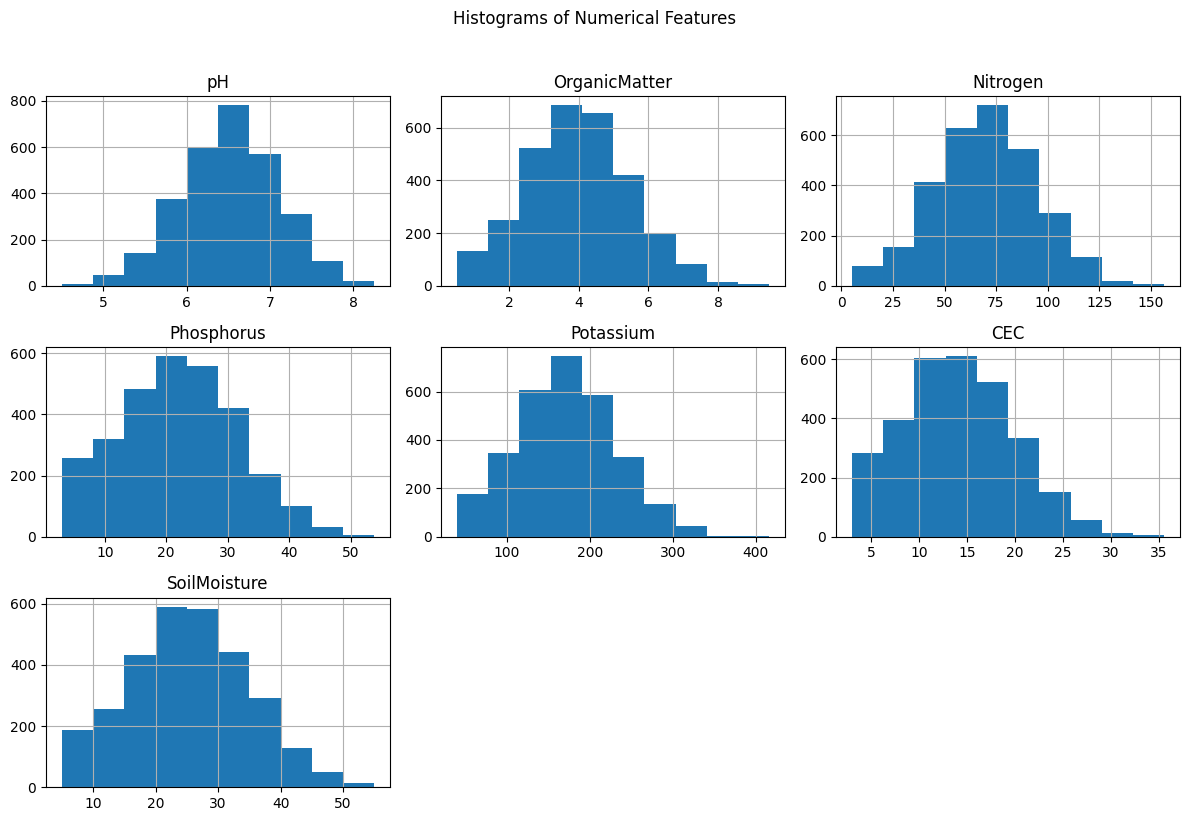

In [8]:
# Histograms showing distribution of numerical features
# Adapted from: AI1 Exercise 3 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
df_cleaned.hist(figsize=(12, 8))
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

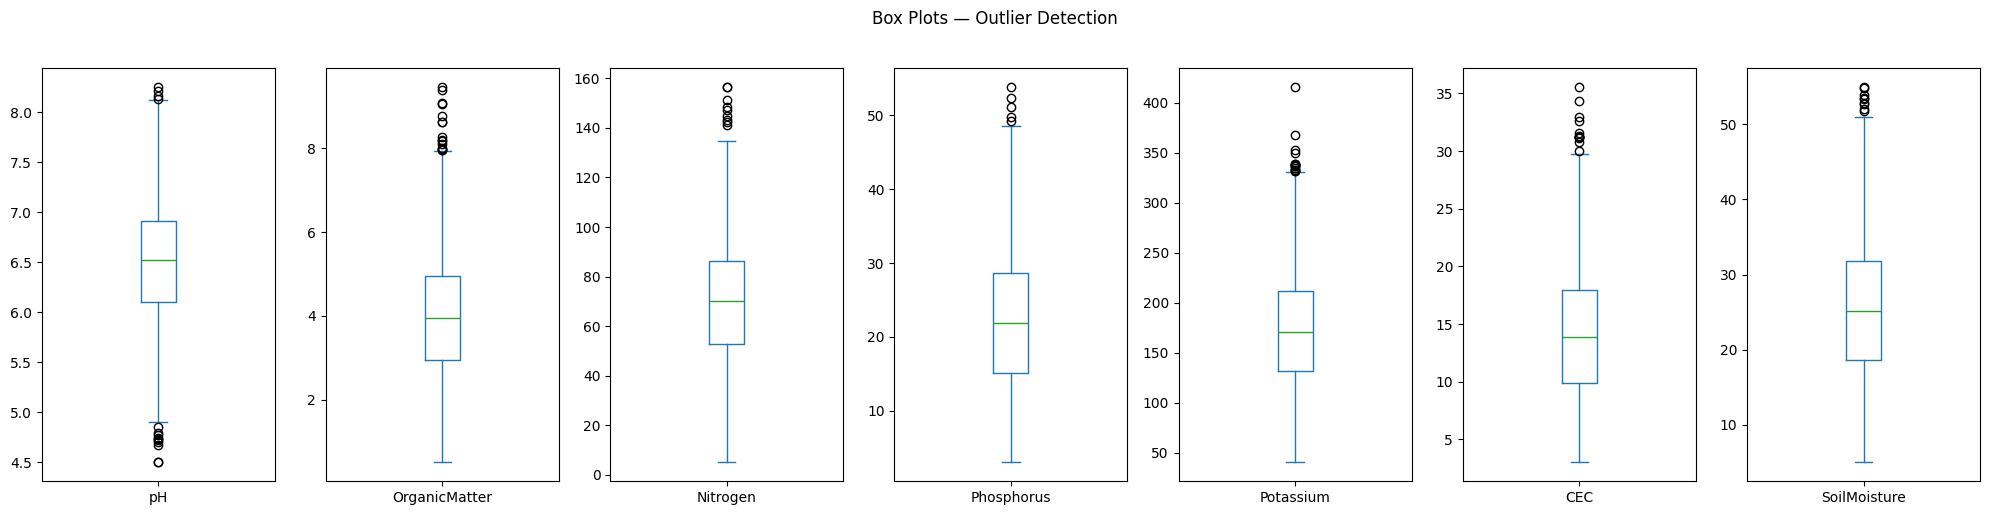

In [9]:
# Box plots to examine outliers and distribution spread
df_cleaned.plot(kind='box', subplots=True, figsize=(20, 5))
plt.suptitle('Box Plots — Outlier Detection', y=1.02)
plt.tight_layout()
plt.show()

**Observation — Box Plots:**
- No extreme outliers requiring removal from any feature
- Some features (e.g. Potassium, Nitrogen) show wider spread — expected in agricultural data
- Features have very different scales: pH ranges 4–8, Potassium ranges 40–400
- **Conclusion:** Outliers exist but are within realistic measurement ranges — no removal needed. StandardScaler will normalise all features before model training.

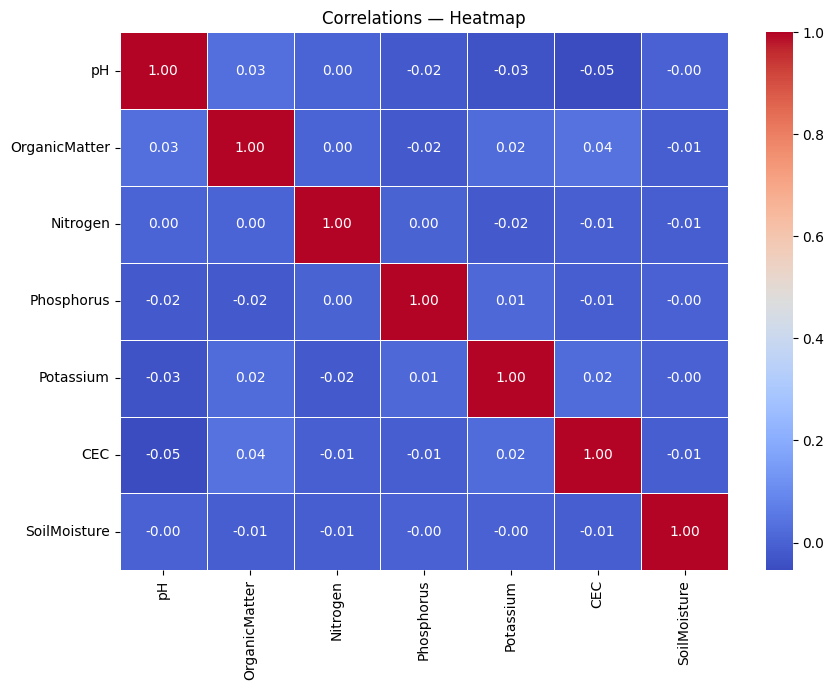

In [10]:
# Correlation heatmap — shows feature relationships
# Values near +1/-1 = strong relationship, near 0 = no relationship
# Adapted from: AI1 Exercise 3 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
corr_matrix = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            linewidths=0.5, fmt='.2f')
plt.title('Correlations — Heatmap')
plt.tight_layout()
plt.show()

Target variable distribution:
SoilStatus
Insufficient    1499
Sufficient      1476
Name: count, dtype: int64

Class proportions:
SoilStatus
Insufficient    0.504
Sufficient      0.496
Name: proportion, dtype: float64


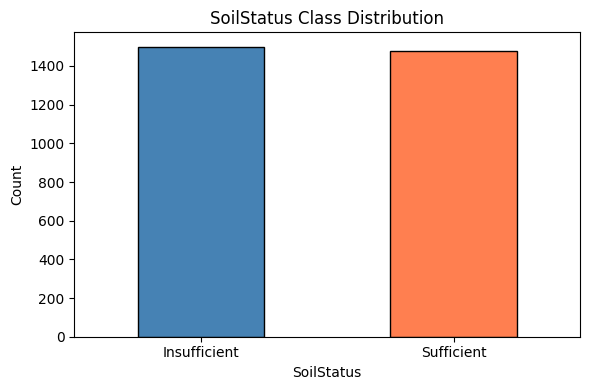

In [11]:
# Target variable distribution — check for class imbalance
print('Target variable distribution:')
print(df_cleaned['SoilStatus'].value_counts())
print()
print('Class proportions:')
print(df_cleaned['SoilStatus'].value_counts(normalize=True).round(3))

df_cleaned['SoilStatus'].value_counts().plot(
    kind='bar', color=['steelblue', 'coral'],
    figsize=(6, 4), edgecolor='black')
plt.title('SoilStatus Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** The dataset is **perfectly balanced** — 1,500 Sufficient and 1,500 Insufficient (50% each). No class imbalance issues. **MCC** is still used as the primary metric because it uses all four confusion matrix values (TP, TN, FP, FN) and is the leaderboard ranking metric.

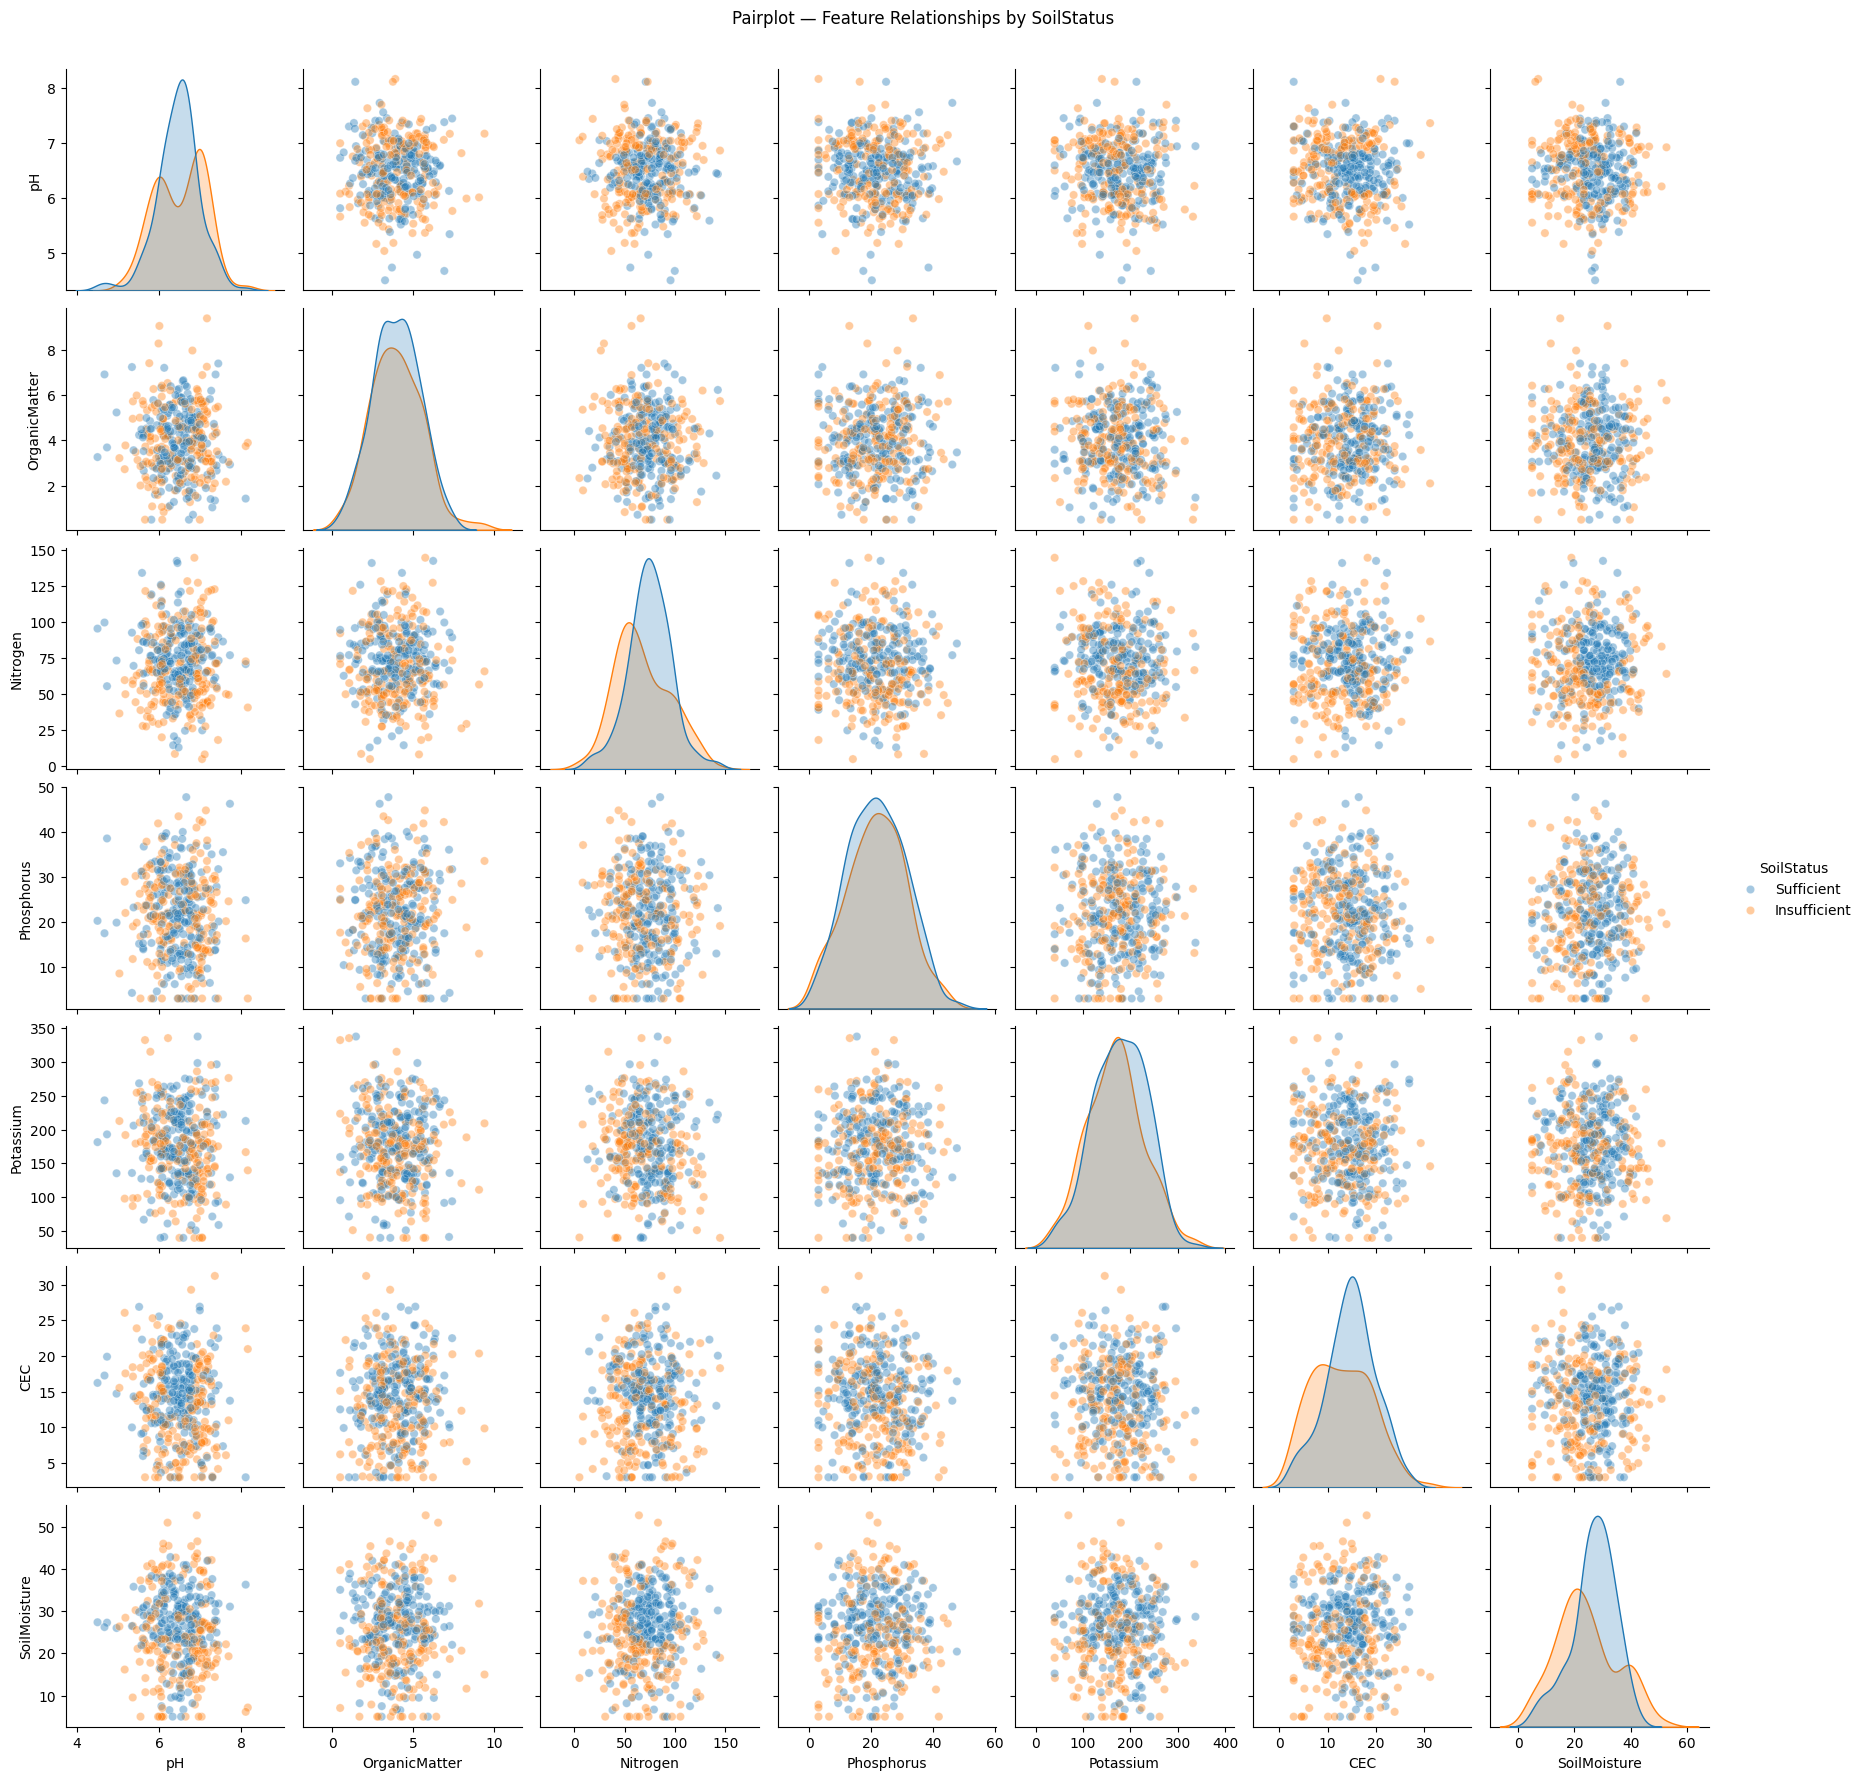

In [12]:
# Pairplot coloured by target variable — visualise class separation
# hue='SoilStatus' colours data points by class
# Adapted from: AI1 Exercise 3 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
num_features = df_cleaned.select_dtypes(include=[float]).columns.tolist()
sns.pairplot(
    df_cleaned[num_features + ['SoilStatus']].sample(400, random_state=42),
    hue='SoilStatus',
    plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot — Feature Relationships by SoilStatus', y=1.02)
plt.show()

In [13]:
# Output all categorical features and their unique values
# This determines whether to use one-hot or ordinal encoding
# Adapted from: AI1 Exercise 4 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
cat_cols_check = df_cleaned.select_dtypes(exclude=[float, int]).columns
for col in cat_cols_check:
    print(col)
    print(df_cleaned[col].unique())
    print()

SoilType
['Sand' 'Loam' 'Clay' nan]

Region
['South' 'East' 'West' 'North' nan]

CropType
['Rape' 'Maize' 'Wheat' 'Barley' nan]

IrrigationLevel
['Low' 'Medium' 'High' nan]

FertilizerUse
['Moderate' 'Intensive' nan]

SoilStatus
['Sufficient' 'Insufficient']



**Encoding decisions based on unique values:**
- `SoilType` (Clay, Loam, Sand) → **Nominal** (no natural order) → **One-Hot Encoding** (`pd.get_dummies`, `drop_first=True`)
- `Region` (North, South, East, West) → **Nominal** → **One-Hot Encoding**
- `CropType` (Wheat, Maize, Barley, Rape) → **Nominal** → **One-Hot Encoding**
- `IrrigationLevel` (Low < Medium < High) → **Ordinal** (has natural order) → **Integer Encoding** `{Low: 0, Medium: 1, High: 2}`
- `FertilizerUse` (None < Moderate < Intensive) → **Ordinal** → **Integer Encoding** `{None: 0, Moderate: 1, Intensive: 2}`

**Why `drop_first=True` for One-Hot?** With 3 soil types, knowing Loam=0 and Sand=0 tells us it must be Clay — the third column is redundant and can cause multicollinearity.

---
# Part 2 — Data Split, Pre-processing and MyComPuTeMetRIX


---

## Theory: Why Split Before Pre-processing?

**The most important rule: Data must be split BEFORE pre-processing.**

If we pre-process ALL data first (e.g. compute mean for imputation using test samples), statistics from the test set influence the training phase. This is called **information leakage** — the model indirectly 'sees' test data, leading to overly optimistic performance estimates that do not hold in deployment.

**Correct order:**
1. Split data first
2. **Fit** all preprocessing tools (imputer, scaler) on **training data only**
3. **Apply** (transform) the same fitted tools to validation and test data

**Splitting strategy: 5-fold StratifiedKFold + separate test set**
- Test set (20%) → completely held out, used ONCE at the end
- Remaining 80% → 5-fold `StratifiedKFold` cross-validation for model selection
- `StratifiedKFold` → ensures same 50/50 class ratio in each fold (important for classification)
- **Alternative (simple split):** faster but less reliable — depends on which samples fell into which split. Cross-validation is more stable since every sample is used for validation exactly once.

**Reference:** Adapted from AI1 Exercise 4 & 6 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [14]:
# Splitting the features and target variable
# Using df_cleaned (rows with >50% missing already removed)
# Adapted from: AI1 Exercise 4 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
X = df_cleaned.drop(columns=['SoilStatus'])
y = df_cleaned['SoilStatus']

# Identify numerical and categorical columns for preprocessing
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols  = X.select_dtypes(exclude=[np.number]).columns

print('Features shape: ' + str(X.shape))
print('Target shape:   ' + str(y.shape))
print('Numerical columns: ' + str(list(num_cols)))
print('Categorical columns: ' + str(list(cat_cols)))

Features shape: (2975, 12)
Target shape:   (2975,)
Numerical columns: ['pH', 'OrganicMatter', 'Nitrogen', 'Phosphorus', 'Potassium', 'CEC', 'SoilMoisture']
Categorical columns: ['SoilType', 'Region', 'CropType', 'IrrigationLevel', 'FertilizerUse']


In [15]:
# Create Train+Validation and Test split
# Split BEFORE any preprocessing — avoids information leakage!
# Adapted from: AI1 Exercise 6 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Save raw (unprocessed) copy needed for final retraining step
X_train_val_raw = X_train_val.copy()

# Define 5-fold StratifiedKFold — same cv object used for ALL models (ensures fair comparison)
# StratifiedKFold for classification keeps the same class ratio in each fold
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

print('Train+Val size: ' + str(X_train_val.shape[0]) +
      ' (' + str(round(X_train_val.shape[0]/len(X)*100)) + '%)')
print('Test size:      ' + str(X_test.shape[0]) +
      ' (' + str(round(X_test.shape[0]/len(X)*100)) + '%)')
print('CV strategy:    StratifiedKFold, n_splits=5')

Train+Val size: 2380 (80%)
Test size:      595 (20%)
CV strategy:    StratifiedKFold, n_splits=5


---
## MyComPuTeMetRIX — Classification Metrics Function

## Theory: Classification Metrics

A metric is a **score that tells us how good or bad our model is**. For classification, we build on the **Confusion Matrix**:

|  | Actual Sufficient | Actual Insufficient |
|---|---|---|
| **Predicted Sufficient** | TP | FP (Type 1 error) |
| **Predicted Insufficient** | FN (Type 2 error) | TN |

Derived metrics:
- **Accuracy** = (TP+TN)/Total — misleading for imbalanced data
- **Precision** = TP/(TP+FP) — of predicted Sufficient, how many truly are?
- **Recall** = TP/(TP+FN) — of actual Sufficient, how many did we detect?
- **F1** = harmonic mean of Precision and Recall
- **MCC** = $(TP \cdot TN - FP \cdot FN) / \sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}$
  - Best single metric — uses all four confusion matrix values
  - Range: -1 (completely wrong) to 0 (random) to +1 (perfect)
  - **The leaderboard ranks teams by MCC** → we optimise for MCC throughout

**Reference:** AI1 Lecture 2 — Evaluation Metrics (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [16]:
# Required function — implements all classification metrics
# Adapted from: AI1 Exercise 8 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
def MyComPuTeMetRIX(y_true, y_pred):
    """
    Calculate and display all classification metrics.
    Required function for AI1 Group Project — ExamGroup9.

    Parameters:
        y_true : array-like, true class labels
        y_pred : array-like, predicted class labels

    Returns:
        metrics : dict with Accuracy, Precision, Recall, F1, MCC
    """
    metrics = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall':    recall_score(y_true, y_pred, average='weighted'),
        'F1':        f1_score(y_true, y_pred, average='weighted'),
        'MCC':       matthews_corrcoef(y_true, y_pred)
    }
    print('Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    print()
    print('Metrics:')
    for name, value in metrics.items():
        print(f'  {name}: {value:.4f}')
    return metrics

print('MyComPuTeMetRIX defined successfully!')

MyComPuTeMetRIX defined successfully!


---
## Feature Engineering + Pre-processing Helper

## Theory: Feature Engineering

Feature engineering means **creating new useful features from existing ones** to help the model learn patterns it would otherwise miss in the raw features.

**Do we use missing values in feature engineering?**
No — feature engineering is applied **after imputation**, inside the preprocessing pipeline. By the time `add_engineered_features()` is called, all NaN values have already been filled by `SimpleImputer`. This is critical: if we applied feature engineering before imputation, arithmetic on NaN values would produce more NaN values (e.g. NaN / Phosphorus = NaN).

**Why do we do feature engineering?**
- Raw features capture individual measurements but not their relationships
- The model cannot automatically create ratios or products from raw columns
- Domain knowledge tells us certain combinations are agronomically meaningful:
  - N:P ratio → nutrient balance is more informative than N or P alone
  - pH × CEC → combined buffering capacity of the soil
  - Nitrogen² → diminishing returns of nitrogen are non-linear
  - K/CEC → fraction of exchange sites occupied by potassium
  - OrganicMatter × Nitrogen → organic nitrogen pool in the soil
- These new features give the model additional signal to learn from

**Why after splitting and inside the CV loop?**
Feature engineering here uses only arithmetic on already-imputed values — no statistics from the data are learned. So technically there is no leakage risk. However, we still apply it inside the preprocessing function for consistency and to ensure train and val/test go through identical steps.

**Our engineered features (soil domain knowledge):**
- `N_P_ratio` = Nitrogen / (Phosphorus + 1) → nutrient balance indicator
- `pH_CEC_product` = pH × CEC → combined soil buffering capacity
- `Nitrogen_squared` = Nitrogen² → captures non-linear nitrogen effects
- `K_CEC_ratio` = Potassium / (CEC + 1) → potassium saturation index
- `OM_N_product` = OrganicMatter × Nitrogen → soil organic nitrogen content

## Theory: Pre-processing Steps

Pre-processing converts raw data into a format ML models can use:
1. **Imputation** — fill NaN with mean (numerical) or most frequent (categorical); always `fit_transform` on train, `transform` on val/test
2. **Feature Engineering** — create new features from imputed values (arithmetic only — no leakage)
3. **Encoding** — nominal features → One-Hot (`pd.get_dummies`, `drop_first=True`); ordinal features → Integer (`.map({...})`)
4. **Column alignment** — `.reindex()` ensures val/test have same columns as train (a fold may lack a rare category)
5. **Scaling** — `StandardScaler` (mean=0, std=1); essential for KNN, SVM, Logistic Regression

**Everything done INSIDE the CV loop** → each fold completely independent, no leakage between folds.

**Reference:** Adapted from AI1 Exercise 4, 5, 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [17]:
# Feature engineering function
# Adapted from: AI1 Exercise 5 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
def add_engineered_features(df_in):
    """
    Add domain-informed engineered features from existing columns.
    Applied identically to train and val/test after imputation.
    Checks column existence for robustness.
    """
    df = df_in.copy()
    # Nitrogen-to-Phosphorus ratio: important nutrient balance indicator
    if 'Nitrogen' in df.columns and 'Phosphorus' in df.columns:
        df['N_P_ratio'] = df['Nitrogen'] / (df['Phosphorus'] + 1)
    # pH times CEC: combined soil chemistry interaction (buffering capacity)
    if 'pH' in df.columns and 'CEC' in df.columns:
        df['pH_CEC_product'] = df['pH'] * df['CEC']
    # Nitrogen squared: captures non-linear nitrogen effect on soil status
    if 'Nitrogen' in df.columns:
        df['Nitrogen_squared'] = df['Nitrogen'] ** 2
    # Potassium-to-CEC ratio: potassium saturation index
    if 'Potassium' in df.columns and 'CEC' in df.columns:
        df['K_CEC_ratio'] = df['Potassium'] / (df['CEC'] + 1)
    # OrganicMatter times Nitrogen: soil organic nitrogen content proxy
    if 'OrganicMatter' in df.columns and 'Nitrogen' in df.columns:
        df['OM_N_product'] = df['OrganicMatter'] * df['Nitrogen']
    return df

print('add_engineered_features() defined!')

add_engineered_features() defined!


In [18]:
# Pre-processing + feature engineering helper — applied inside each CV fold
# Adapted from: AI1 Exercise 4, 5, 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
def preprocess_fold(X_train_f, X_val_f, num_cols, cat_cols):
    """
    Full preprocessing pipeline for one CV fold.
    Fit all tools on training data only — apply to both splits.
    Steps: Impute → Feature Engineer → Encode → Align → Scale
    """
    # ---- STEP 1: IMPUTATION ----
    # Treat numerically and categorically separately
    # Imputing numerical columns (mean value)
    imputer_num = SimpleImputer(strategy='mean')
    # Imputing categorical columns (most frequent value)
    imputer_cat = SimpleImputer(strategy='most_frequent')

    # Store copies to avoid modifying original
    X_train_imputed = X_train_f.copy()
    X_val_imputed   = X_val_f.copy()

    # fit_transform on train: learns statistics + applies them
    X_train_imputed[num_cols] = imputer_num.fit_transform(X_train_f[num_cols])
    X_train_imputed[cat_cols] = imputer_cat.fit_transform(X_train_f[cat_cols])
    # transform only on val: applies same statistics (no refitting!)
    X_val_imputed[num_cols] = imputer_num.transform(X_val_f[num_cols])
    X_val_imputed[cat_cols] = imputer_cat.transform(X_val_f[cat_cols])

    # ---- STEP 2: FEATURE ENGINEERING ----
    # Applied identically to both splits — no leakage (pure arithmetic)
    X_train_fe = add_engineered_features(X_train_imputed)
    X_val_fe   = add_engineered_features(X_val_imputed)

    # ---- STEP 3: ENCODING ----
    # One-Hot Encoding for nominal features (no natural order)
    X_train_cod = pd.get_dummies(
        X_train_fe, columns=['SoilType', 'Region', 'CropType'], drop_first=True)
    X_val_cod   = pd.get_dummies(
        X_val_fe,   columns=['SoilType', 'Region', 'CropType'], drop_first=True)

    # Ordinal Encoding for features with a natural order
    X_train_cod['IrrigationLevel'] = X_train_fe['IrrigationLevel'].map(
        {'Low': 0, 'Medium': 1, 'High': 2})
    X_val_cod['IrrigationLevel']   = X_val_fe['IrrigationLevel'].map(
        {'Low': 0, 'Medium': 1, 'High': 2})
    X_train_cod['FertilizerUse'] = X_train_fe['FertilizerUse'].map(
        {'None': 0, 'Moderate': 1, 'Intensive': 2})
    X_val_cod['FertilizerUse']   = X_val_fe['FertilizerUse'].map(
        {'None': 0, 'Moderate': 1, 'Intensive': 2})

    # ---- STEP 4: COLUMN ALIGNMENT ----
    # If a category is absent in a fold, its column is missing in val → align
    X_val_cod = X_val_cod.reindex(columns=X_train_cod.columns, fill_value=0)

    # ---- STEP 5: SCALING ----
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_cod)  # fit + transform on train
    X_val_scaled   = scaler.transform(X_val_cod)         # transform only on val

    return X_train_scaled, X_val_scaled, X_train_cod.columns

print('preprocess_fold() defined successfully!')

preprocess_fold() defined successfully!


---
# Part 3 — Model Training: KNN and Logistic Regression
*Responsible: Adey Purohit*

---

## Theory: K-Nearest Neighbours (KNN)

KNN is a **lazy learner** — it stores all training data and makes predictions at test time by:
1. Computing distance from a new sample to **all** training samples
2. Finding the $k$ nearest neighbours
3. Taking the **majority vote** (classification)

**Distance metrics** (hyperparameter `p`):
- $p=1$: Manhattan distance $d = \sum|x_i - y_i|$
- $p=2$: Euclidean distance $d = \sqrt{\sum(x_i - y_i)^2}$

**Hyperparameter `k`:**
- Small $k$ → sensitive to noise → overfitting
- Large $k$ → predicts majority class → underfitting
- Odd $k$ recommended for binary classification to avoid ties

**Why scaling is essential for KNN:** Without scaling, features with large value ranges (e.g. Potassium: 40–400) dominate the distance calculation, making small-range features (pH: 4–8) almost irrelevant — even if pH is highly predictive.

**Why Grid Search for KNN instead of Random Search?**

KNN has only two hyperparameters:
- `n_neighbors`: values 1 to 50 → 50 options
- `p`: values 1 or 2 → 2 options
- Total search space: 50 × 2 = **100 combinations**

Grid Search tests all 100 combinations exhaustively — this gives
**100% coverage** with no gaps and no duplicate combinations.

Random Search with `n_iter=40` only tests 40% of the space and
wastes runs on duplicate combinations (same k and p tested twice),
which is inefficient when the full grid is this small.

**Consistency rule applied across all models:**
- Small search space (≤300 combinations) → **Grid Search**
  (KNN: 100, Logistic Regression: 264, SVM: 180)
- Large search space (>1,000 combinations) → **Random Search**
  (Random Forest: 1,440, XGBoost: 4,320)

KNN trains in effectively zero time — it stores data rather than
learning parameters — so testing all 100 combinations × 5 folds
= 500 runs completes in seconds.

**Reference:** Adapted from AI1 Exercise 6 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [19]:
# KNN — Grid Search (100 combinations, 100% coverage)
# Search space is small (50 × 2 = 100) → Grid Search is more appropriate
# than Random Search — tests every combination with no gaps or duplicates
# Adapted from: AI1 Exercise 6 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
param_grid_knn = {
    'n_neighbors': list(range(1, 51)),  # k from 1 to 50
    'p': [1, 2]                         # 1=Manhattan, 2=Euclidean
}
# Grid Search: all 50 × 2 = 100 combinations tested (100% coverage)
param_combinations_knn = list(ParameterGrid(param_grid_knn))

print('KNN — Grid Search, ' + str(len(param_combinations_knn)) + ' combinations')

KNN — Grid Search, 100 combinations


In [20]:
# Saving the validation results
# ATTENTION: Renamed val_scores to val_scores_knn for each model (Exercise 11 pattern)
# Adapted from: AI1 Exercise 6 & 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
val_scores_knn = []

# We iterate over all hyperparameter combinations
for params in param_combinations_knn:
    model = KNeighborsClassifier(**params)
    fold_val_scores_knn = []
    print('New hyperparameter combination: ' + str(params))

    # cross-validation
    for train_index, val_index in cv.split(X_train_val, y_train_val):
        print('   New Fold launches')
        X_train_fold = X_train_val.iloc[train_index]
        X_val_fold   = X_train_val.iloc[val_index]
        y_train_fold = y_train_val.iloc[train_index]
        y_val_fold   = y_train_val.iloc[val_index]

        X_train_scaled, X_val_scaled, _ = preprocess_fold(
            X_train_fold, X_val_fold, num_cols, cat_cols)

        model.fit(X_train_scaled, y_train_fold)
        y_val_pred = model.predict(X_val_scaled)
        score = matthews_corrcoef(y_true=y_val_fold, y_pred=y_val_pred)
        fold_val_scores_knn.append(score)
        print('   Score: ' + str(score))

    avg_score = np.mean(fold_val_scores_knn)
    val_scores_knn.append(avg_score)
    print('   Average MCC: ' + str(avg_score))

print('\nKNN — Best validation MCC: ' + str(max(val_scores_knn)))
best_knn_params = param_combinations_knn[val_scores_knn.index(max(val_scores_knn))]
print('KNN — Best hyperparameters: ' + str(best_knn_params))

New hyperparameter combination: {'n_neighbors': 1, 'p': 1}
   New Fold launches
   Score: 0.24962219107463887
   New Fold launches
   Score: 0.25261750453760107
   New Fold launches
   Score: 0.25819888974716115
   New Fold launches
   Score: 0.2937602825610479
   New Fold launches
   Score: 0.35002480433121835
   Average MCC: 0.2808447344503335
New hyperparameter combination: {'n_neighbors': 1, 'p': 2}
   New Fold launches
   Score: 0.17971099617669406
   New Fold launches
   Score: 0.19475850049231597
   New Fold launches
   Score: 0.15193273925925235
   New Fold launches
   Score: 0.20070953607044617
   New Fold launches
   Score: 0.3296531819034666
   Average MCC: 0.21135299078043507
New hyperparameter combination: {'n_neighbors': 2, 'p': 1}
   New Fold launches
   Score: 0.25708188899174805
   New Fold launches
   Score: 0.29383557458494153
   New Fold launches
   Score: 0.26652872482131357
   New Fold launches
   Score: 0.2933430843425786
   New Fold launches
   Score: 0.33710865

---
## Theory: Logistic Regression with ElasticNet Regularisation

Logistic Regression predicts the **probability** of class membership using the sigmoid function:
$$f(\mathbf{x}) = \frac{1}{1 + e^{-\mathbf{x}\boldsymbol{\beta}}}$$

If $f(\mathbf{x}) > 0.5$ → predict Sufficient; else → predict Insufficient.

**What is regularisation and why do we use it?**
Without regularisation, the model can assign very large coefficients to features — fitting the training data perfectly but generalising poorly to new data (overfitting). Regularisation adds a penalty term to the loss function that discourages large coefficients, forcing the model to be simpler and more general.

**ElasticNet regularisation** combines two penalty types:
- **L1 (LASSO):** $\Omega = \sum|\beta_j|$ → sets some coefficients to exactly **zero** (automatic feature selection — irrelevant features are removed)
- **L2 (Ridge):** $\Omega = \sum\beta_j^2$ → smoothly **shrinks all** coefficients towards zero (keeps all features but reduces their influence)
- **ElasticNet:** weighted combination: $\Omega = l1\_ratio \cdot L1 + (1 - l1\_ratio) \cdot L2$
  - `l1_ratio=1.0` → pure L1 (LASSO): aggressive feature selection
  - `l1_ratio=0.0` → pure L2 (Ridge): smooth shrinkage of all features
  - `l1_ratio=0.5` → equal mix of both

**`C`**: inverse of regularisation strength:
- Large `C` → weak regularisation → complex model → overfitting risk
- Small `C` → strong regularisation → simpler model → underfitting risk

**`solver='saga'`**: the only sklearn solver supporting ElasticNet penalty — required.

**Why Grid Search for Logistic Regression?**
Logistic Regression has two real hyperparameters (`C` and `l1_ratio`), plus fixed `penalty` and `solver`. The grid has ~132 combinations — small enough for exhaustive Grid Search. Logistic Regression also trains very fast so Grid Search is computationally feasible here, giving complete coverage of the parameter space.


- Logistic Regression uses Grid Search  because its parameter space is a fixed list of 132 combinations, making Grid Search practical

**Reference:** Adapted from AI1 Exercise 8 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [21]:
# Logistic Regression parameter grid — Grid Search
# Using np.arange step of 0.25 for finer C coverage (more values between -3 and 3)
# Adapted from: AI1 Exercise 8 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
param_grid_logreg = {
    'C':        [10**n for n in np.arange(-3, 3, 0.25)],
    'l1_ratio': np.arange(0, 1.1, 0.1).tolist(),
    'penalty':  ['elasticnet'],
    'solver':   ['saga']
}
param_combinations_logreg = list(ParameterGrid(param_grid_logreg))
print('Logistic Regression — Grid Search, ' + str(len(param_combinations_logreg)) + ' combinations')

Logistic Regression — Grid Search, 264 combinations


In [22]:
# Saving the validation results
# Adapted from: AI1 Exercise 8 & 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
val_scores_logreg = []

for params in param_combinations_logreg:
    model = LogisticRegression(**params, max_iter=1000)
    fold_val_scores_logreg = []
    print('New hyperparameter combination: ' + str(params))

    for train_index, val_index in cv.split(X_train_val, y_train_val):
        print('   New Fold launches')
        X_train_fold = X_train_val.iloc[train_index]
        X_val_fold   = X_train_val.iloc[val_index]
        y_train_fold = y_train_val.iloc[train_index]
        y_val_fold   = y_train_val.iloc[val_index]

        X_train_scaled, X_val_scaled, _ = preprocess_fold(
            X_train_fold, X_val_fold, num_cols, cat_cols)

        model.fit(X_train_scaled, y_train_fold)
        y_val_pred = model.predict(X_val_scaled)
        score = matthews_corrcoef(y_true=y_val_fold, y_pred=y_val_pred)
        fold_val_scores_logreg.append(score)
        print('   Score: ' + str(score))

    avg_score = np.mean(fold_val_scores_logreg)
    val_scores_logreg.append(avg_score)
    print('   Average MCC: ' + str(avg_score))

print('\nLogistic Regression — Best validation MCC: ' + str(max(val_scores_logreg)))
best_logreg_params = param_combinations_logreg[val_scores_logreg.index(max(val_scores_logreg))]
print('Logistic Regression — Best hyperparameters: ' + str(best_logreg_params))

New hyperparameter combination: {'C': np.float64(0.001), 'l1_ratio': 0.0, 'penalty': 'elasticnet', 'solver': 'saga'}
   New Fold launches
   Score: 0.3361530261082018
   New Fold launches
   Score: 0.25575030335373816
   New Fold launches
   Score: 0.29448329448329447
   New Fold launches
   Score: 0.28562784209721626
   New Fold launches
   Score: 0.3136332910001037
   Average MCC: 0.2971295514085109
New hyperparameter combination: {'C': np.float64(0.001), 'l1_ratio': 0.1, 'penalty': 'elasticnet', 'solver': 'saga'}
   New Fold launches
   Score: 0.302380743654764
   New Fold launches
   Score: 0.26399431606166374
   New Fold launches
   Score: 0.26454419638256255
   New Fold launches
   Score: 0.24748793740704958
   New Fold launches
   Score: 0.25279066285342
   Average MCC: 0.26623957127189196
New hyperparameter combination: {'C': np.float64(0.001), 'l1_ratio': 0.2, 'penalty': 'elasticnet', 'solver': 'saga'}
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   Ne

---
# Part 4 — Model Training: SVM and Random Forest


---

## Theory: Support Vector Machine (SVM)

SVM finds the **hyperplane with maximum margin** between classes. The closest training points to the boundary are **support vectors** — they define the boundary.

**Soft-Margin SVM** allows misclassifications, controlled by `C`:
- Large `C` → strict, few misclassifications → overfitting risk
- Small `C` → flexible, more misclassifications → underfitting risk

**Kernel trick** — transforms data to higher dimensions where it becomes linearly separable without computing the transformation explicitly:
- **Linear kernel:** straight decision boundary
- **RBF kernel:** $k(x,x')=\exp(-\gamma||x-x'||^2)$ — can model any boundary shape
  - Large $\gamma$ → local influence → complex boundary → overfitting
  - Small $\gamma$ → global influence → smooth boundary → underfitting

**Why a list of dicts for param_grid?** Different kernels have different hyperparameters. `gamma` only applies to RBF — not linear. A list of dicts lets `ParameterGrid` create correct combinations per kernel separately.

**Scaling essential for SVM** — uses distances internally.

**Reference:** Adapted from AI1 Exercise 9 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [23]:
# SVM parameter grid — list of dicts (different kernels, different hyperparameters)
# Extended C and gamma ranges for better coverage
# Adapted from: AI1 Exercise 9 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
param_grid_svm = [
    {
        # Linear kernel — only needs C
        'C':      [10**n for n in np.arange(-5, 4, 0.5)],
        'kernel': ['linear']
    },
    {
        # RBF kernel — needs C AND gamma
        'C':      [10**n for n in np.arange(-5, 4, 0.5)],
        'kernel': ['rbf'],
        'gamma':  ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
    }
]
param_combinations_svm = list(ParameterGrid(param_grid_svm))
print('SVM — Grid Search, ' + str(len(param_combinations_svm)) + ' combinations (linear + RBF)')

SVM — Grid Search, 180 combinations (linear + RBF)


In [24]:
# Saving the validation results
# Adapted from: AI1 Exercise 9 & 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
val_scores_svm = []

for params in param_combinations_svm:
    model = SVC(**params)
    fold_val_scores_svm = []
    print('New hyperparameter combination: ' + str(params))

    for train_index, val_index in cv.split(X_train_val, y_train_val):
        print('   New Fold launches')
        X_train_fold = X_train_val.iloc[train_index]
        X_val_fold   = X_train_val.iloc[val_index]
        y_train_fold = y_train_val.iloc[train_index]
        y_val_fold   = y_train_val.iloc[val_index]

        X_train_scaled, X_val_scaled, _ = preprocess_fold(
            X_train_fold, X_val_fold, num_cols, cat_cols)

        model.fit(X_train_scaled, y_train_fold)
        y_val_pred = model.predict(X_val_scaled)
        score = matthews_corrcoef(y_true=y_val_fold, y_pred=y_val_pred)
        fold_val_scores_svm.append(score)
        print('   Score: ' + str(score))

    avg_score = np.mean(fold_val_scores_svm)
    val_scores_svm.append(avg_score)
    print('   Average MCC: ' + str(avg_score))

print('\nSVM — Best validation MCC: ' + str(max(val_scores_svm)))
best_svm_params = param_combinations_svm[val_scores_svm.index(max(val_scores_svm))]
print('SVM — Best hyperparameters: ' + str(best_svm_params))

New hyperparameter combination: {'C': np.float64(1e-05), 'kernel': 'linear'}
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   Average MCC: 0.0
New hyperparameter combination: {'C': np.float64(3.1622776601683795e-05), 'kernel': 'linear'}
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   Average MCC: 0.0
New hyperparameter combination: {'C': np.float64(0.0001), 'kernel': 'linear'}
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   New Fold launches
   Score: 0.0
   Average MCC: 0.0
New hyperparameter combination: {'C': np.float64(0.00031622776601683794), 'kernel': 'linear'}
   New Fold launches
   Score: 0.14810918402703896
   New Fold launches


---
## Theory: Random Forest

Random Forest is a **Bagging** (Bootstrap Aggregating) ensemble method:
1. Creates many **bootstrap samples** (random sampling WITH replacement from training data)
2. Trains a decision tree on each bootstrap sample
3. At each split, considers only a **random subset of features** → reduces correlation between trees, improves diversity
4. Final prediction: **majority vote** of all trees (classification)

**Why better than a single decision tree?**
- A single tree overfits easily — small changes in data produce completely different trees
- Random Forest averages over many diverse trees → much more stable and accurate
- Reduces variance without significantly increasing bias

**Key hyperparameters:**
- `n_estimators` → number of trees (more = more stable, slower)
- `max_depth` → depth per tree (deeper = more complex)
- `max_features` → features considered per split (`'sqrt'` = standard for classification)
- `max_samples` → fraction of data per tree

**Feature importance** directly available via `feature_importances_` attribute.

**Reference:** Adapted from AI1 Exercise 10 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [25]:
# Random Forest parameter grid — Random Search
# Full grid from Exercise 10 with n_iter=100 for better coverage
# Adapted from: AI1 Exercise 10 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200, 500, 1000],
    'max_depth':    [2, 3, 5, 10, None],
    'max_features': ['sqrt', 'log2', None, 0.1, 0.3, 0.5, 0.7, 0.9],
    'max_samples':  [None, 0.1, 0.3, 0.5, 0.7, 0.9]
}
# n_iter=100 gives better coverage of the large search space
param_combinations_rf = list(
    ParameterSampler(param_grid_rf, n_iter=100, random_state=42))
print('Random Forest — Random Search, ' + str(len(param_combinations_rf)) + ' combinations')

Random Forest — Random Search, 100 combinations


In [26]:
# Saving the validation results
# Adapted from: AI1 Exercise 10 & 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
val_scores_rf = []

for params in param_combinations_rf:
    model = RandomForestClassifier(**params, random_state=42)
    fold_val_scores_rf = []
    print('New hyperparameter combination: ' + str(params))

    for train_index, val_index in cv.split(X_train_val, y_train_val):
        print('   New Fold launches')
        X_train_fold = X_train_val.iloc[train_index]
        X_val_fold   = X_train_val.iloc[val_index]
        y_train_fold = y_train_val.iloc[train_index]
        y_val_fold   = y_train_val.iloc[val_index]

        X_train_scaled, X_val_scaled, _ = preprocess_fold(
            X_train_fold, X_val_fold, num_cols, cat_cols)

        model.fit(X_train_scaled, y_train_fold)
        y_val_pred = model.predict(X_val_scaled)
        score = matthews_corrcoef(y_true=y_val_fold, y_pred=y_val_pred)
        fold_val_scores_rf.append(score)
        print('   Score: ' + str(score))

    avg_score = np.mean(fold_val_scores_rf)
    val_scores_rf.append(avg_score)
    print('   Average MCC: ' + str(avg_score))

print('\nRandom Forest — Best validation MCC: ' + str(max(val_scores_rf)))
best_rf_params = param_combinations_rf[val_scores_rf.index(max(val_scores_rf))]
print('Random Forest — Best hyperparameters: ' + str(best_rf_params))

New hyperparameter combination: {'n_estimators': 10, 'max_samples': 0.7, 'max_features': 0.3, 'max_depth': 2}
   New Fold launches
   Score: 0.39355896340746355
   New Fold launches
   Score: 0.44539210973259163
   New Fold launches
   Score: 0.4347579678772314
   New Fold launches
   Score: 0.4326418578919223
   New Fold launches
   Score: 0.4745872605720438
   Average MCC: 0.4361876318962505
New hyperparameter combination: {'n_estimators': 1000, 'max_samples': 0.7, 'max_features': 'sqrt', 'max_depth': 5}
   New Fold launches
   Score: 0.6057507197230612
   New Fold launches
   Score: 0.6596561976025012
   New Fold launches
   Score: 0.6524548080400335
   New Fold launches
   Score: 0.6581737782560516
   New Fold launches
   Score: 0.6893779295766469
   Average MCC: 0.653082686639659
New hyperparameter combination: {'n_estimators': 100, 'max_samples': 0.1, 'max_features': 0.9, 'max_depth': 3}
   New Fold launches
   Score: 0.5927652650476699
   New Fold launches
   Score: 0.6723349553

---
# Part 5 — XGBoost, Model Comparison and Leaderboard
*Responsible: Sudish Kumar Yadav*

---

## Theory: XGBoost — Extreme Gradient Boosting

XGBoost is a **Boosting** ensemble method — trees are trained **sequentially**, each correcting errors of previous trees:
$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

where $\eta$ = learning rate, $h_m$ = new tree correcting residuals of $F_{m-1}$.

**Key difference from Random Forest (Bagging):**
- Random Forest: trees trained **in parallel** (independent bootstrap samples)
- XGBoost: trees trained **sequentially** (each corrects previous errors)

**Key hyperparameters:**
- `n_estimators` → number of boosting rounds (more = stronger, risk of overfitting)
- `max_depth` → depth of each tree (XGBoost usually uses shallow trees: 3-6)
- `learning_rate` → how much each tree corrects errors; smaller = more careful
- `subsample` → fraction of samples per tree → adds randomness, prevents overfitting
- `reg_alpha` → L1 regularisation on weights → prevents overfitting

**Why LabelEncoder?** XGBoost requires numeric labels (0, 1) — our target is text ('Sufficient', 'Insufficient'). `LabelEncoder` converts text → numbers and back.

**Feature importance** via `get_booster().get_score()` — three types: `gain`, `cover`, `weight`.

**Reference:** Adapted from AI1 Exercise 10 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [27]:
# XGBoost parameter grid — following professor's guidelines
# Max n_estimators = 500, max combinations = 100
# Adapted from: AI1 Exercise 10 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
param_grid_xgb = {
    'n_estimators':  [10, 50, 100, 200, 500],   # max 500 as per professor
    'max_depth':     [2, 3, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
    'subsample':     [0.1, 0.3, 0.5, 0.7, 0.9, 1],
    'reg_alpha':     [0, 0.01, 0.1, 0.5, 1]
}
# Random Search — n_iter=100 (max as per professor's guidelines)
param_combinations_xgb = list(
    ParameterSampler(param_grid_xgb, n_iter=100, random_state=42))

print('XGBoost — Random Search, ' + str(len(param_combinations_xgb)) + ' combinations')

# LabelEncoder for XGBoost — converts text labels to numeric (required by XGBoost)
le = LabelEncoder()

XGBoost — Random Search, 100 combinations


In [28]:
# Saving the validation results
# Adapted from: AI1 Exercise 10 & 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
val_scores_xgb = []

# We iterate over all hyperparameter combinations
for params in param_combinations_xgb:
    model = XGBClassifier(
        **params,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
    fold_val_scores_xgb = []
    print('New hyperparameter combination: ' + str(params))

    # cross-validation
    for train_index, val_index in cv.split(X_train_val, y_train_val):
        print('   New Fold launches')
        X_train_fold = X_train_val.iloc[train_index]
        X_val_fold   = X_train_val.iloc[val_index]
        y_train_fold = y_train_val.iloc[train_index]
        y_val_fold   = y_train_val.iloc[val_index]

        X_train_scaled, X_val_scaled, _ = preprocess_fold(
            X_train_fold, X_val_fold, num_cols, cat_cols)

        # Encode labels: XGBoost needs numeric 0/1 not text
        y_train_fold_enc = le.fit_transform(y_train_fold)
        y_val_fold_enc   = le.transform(y_val_fold)

        model.fit(X_train_scaled, y_train_fold_enc)
        y_val_pred_enc = model.predict(X_val_scaled)
        # Decode back to text labels for MCC calculation
        y_val_pred = le.inverse_transform(y_val_pred_enc)

        score = matthews_corrcoef(y_true=y_val_fold, y_pred=y_val_pred)
        fold_val_scores_xgb.append(score)
        print('   Score: ' + str(score))

    avg_score = np.mean(fold_val_scores_xgb)
    val_scores_xgb.append(avg_score)
    print('   Average MCC: ' + str(avg_score))

print('\nXGBoost — Best validation MCC: ' + str(max(val_scores_xgb)))
best_xgb_params = param_combinations_xgb[val_scores_xgb.index(max(val_scores_xgb))]
print('XGBoost — Best hyperparameters: ' + str(best_xgb_params))

New hyperparameter combination: {'subsample': 0.5, 'reg_alpha': 0.5, 'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.1}
   New Fold launches
   Score: 0.7604607415863474
   New Fold launches
   Score: 0.7519854861971579
   New Fold launches
   Score: 0.7731949961423378
   New Fold launches
   Score: 0.7313627897102313
   New Fold launches
   Score: 0.7563710421213214
   Average MCC: 0.7546750111514792
New hyperparameter combination: {'subsample': 1, 'reg_alpha': 0.01, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
   New Fold launches
   Score: 0.8404407668684415
   New Fold launches
   Score: 0.8066373478867518
   New Fold launches
   Score: 0.844782999321425
   New Fold launches
   Score: 0.8784371573895506
   New Fold launches
   Score: 0.8655577969965123
   Average MCC: 0.8471712136925362
New hyperparameter combination: {'subsample': 0.7, 'reg_alpha': 0.01, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.5}
   New Fold launches
   Score: 0.8066831402133

---
## Model Comparison

## Theory: Fair Model Comparison

For comparison to be **fair**, all models must be evaluated on the **same validation data** using the **same cross-validation folds**. This is ensured by using the **same `cv` object** (with `random_state=42`) for every model.

We compare the **best validation MCC** of each model — the score achieved by the best hyperparameter combination found per model. The model with the highest best validation MCC becomes the final prediction model.

**Alternative comparison approach (not used here):** Fix one set of hyperparameters per model and compare directly — less fair because hyperparameter optimisation is unequal. Our approach (optimise each model first, then compare best) is the correct one from Exercise 11.

**Reference:** Adapted from AI1 Exercise 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [29]:
# Compare all optimised models — same CV folds used for all (fair!)
# Adapted from: AI1 Exercise 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
print('=' * 60)
print('     MODEL COMPARISON RESULTS — ExamGroup9')
print('=' * 60)
print('Model 1 KNN')
print('Best validation result: ' + str(max(val_scores_knn)))
print()
print('Model 2 Logistic Regression')
print('Best validation result: ' + str(max(val_scores_logreg)))
print()
print('Model 3 SVM')
print('Best validation result: ' + str(max(val_scores_svm)))
print()
print('Model 4 Random Forest')
print('Best validation result: ' + str(max(val_scores_rf)))
print()
print('Model 5 XGBoost')
print('Best validation result: ' + str(max(val_scores_xgb)))
print('=' * 60)

     MODEL COMPARISON RESULTS — ExamGroup9
Model 1 KNN
Best validation result: 0.47218486769744245

Model 2 Logistic Regression
Best validation result: 0.3580619791965723

Model 3 SVM
Best validation result: 0.5020211556117982

Model 4 Random Forest
Best validation result: 0.7501257044377556

Model 5 XGBoost
Best validation result: 0.857978520605236


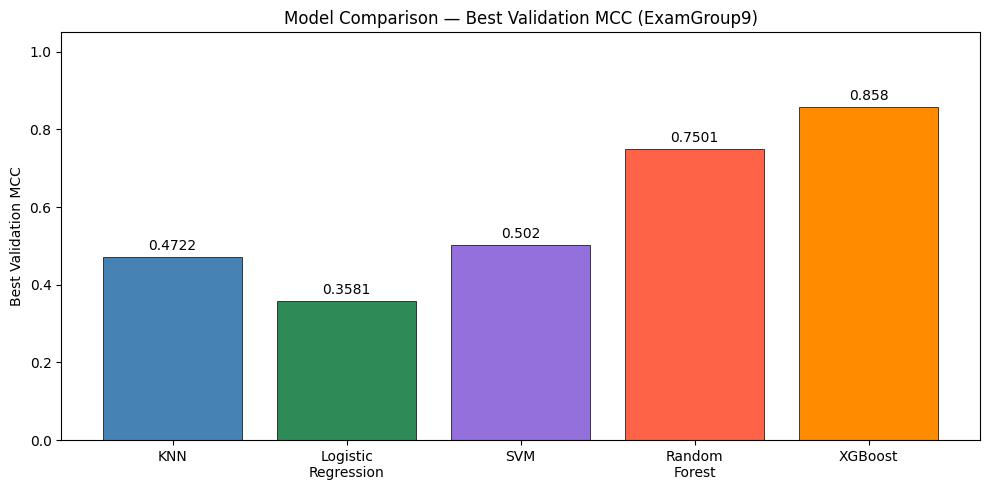

In [30]:
# Visual comparison bar chart
model_names = ['KNN', 'Logistic\nRegression', 'SVM', 'Random\nForest', 'XGBoost']
best_scores = [
    max(val_scores_knn),
    max(val_scores_logreg),
    max(val_scores_svm),
    max(val_scores_rf),
    max(val_scores_xgb)
]
colors = ['steelblue', 'seagreen', 'mediumpurple', 'tomato', 'darkorange']

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, best_scores,
               color=colors, edgecolor='black', linewidth=0.5)
plt.ylabel('Best Validation MCC')
plt.title('Model Comparison — Best Validation MCC (ExamGroup9)')
plt.ylim(0, 1.05)
for bar, score in zip(bars, best_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             str(round(score, 4)),
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [31]:
# Select the best model
# Adapted from: AI1 Exercise 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

# ATTENTION: Select param_combinations and val_scores of the best model
all_best_scores = {
    'KNN':                max(val_scores_knn),
    'Logistic Regression':max(val_scores_logreg),
    'SVM':                max(val_scores_svm),
    'Random Forest':      max(val_scores_rf),
    'XGBoost':            max(val_scores_xgb)
}

# max() with key= returns the model name with the highest score
winner_name  = max(all_best_scores, key=all_best_scores.get)
winner_score = all_best_scores[winner_name]

print('Winner: ' + winner_name)
print('Best validation MCC: ' + str(winner_score))

# Retrieve the optimal hyperparameters for the winner
if winner_name == 'KNN':
    optimal_params = param_combinations_knn[val_scores_knn.index(max(val_scores_knn))]
elif winner_name == 'Logistic Regression':
    optimal_params = param_combinations_logreg[val_scores_logreg.index(max(val_scores_logreg))]
elif winner_name == 'SVM':
    optimal_params = param_combinations_svm[val_scores_svm.index(max(val_scores_svm))]
elif winner_name == 'Random Forest':
    optimal_params = param_combinations_rf[val_scores_rf.index(max(val_scores_rf))]
elif winner_name == 'XGBoost':
    optimal_params = param_combinations_xgb[val_scores_xgb.index(max(val_scores_xgb))]

print('Optimal hyperparameter values: ' + str(optimal_params))

Winner: XGBoost
Best validation MCC: 0.857978520605236
Optimal hyperparameter values: {'subsample': 1, 'reg_alpha': 0.5, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1}


---
## Final Model Retraining

## Theory: Why Retrain on More Data?

After selecting optimal hyperparameters through cross-validation, we retrain the final model on **all available labelled data** (all 3,000 known samples).

**Why all 3,000 samples?**
- Hyperparameters are already selected — no need to hold out validation data any more
- The leaderboard data serves as the independent external test set
- More training data → better model → higher leaderboard MCC
- The professor notes: *"consider whether you still need a separate test set, or whether the leaderboard data is not already sufficient for this"*

The preprocessing (imputer, encoder, scaler) is **refitted on all 3,000 samples** — more data → better statistics.

We also keep the hold-out test set for **internal evaluation** in this notebook.

**Reference:** Adapted from AI1 Exercise 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [32]:
# Pre-processing fitted on ALL known samples for final leaderboard model
# Adapted from: AI1 Exercise 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

# ---- PREPROCESSING ON ALL SAMPLES (for leaderboard model) ----
imputer_num_final = SimpleImputer(strategy='mean')
imputer_cat_final = SimpleImputer(strategy='most_frequent')
scaler_final      = StandardScaler()

# Use .copy() to avoid modifying the original X DataFrame
X_all_imp = X.copy()
X_all_imp[num_cols] = imputer_num_final.fit_transform(X[num_cols])
X_all_imp[cat_cols] = imputer_cat_final.fit_transform(X[cat_cols])

# Feature engineering — applied after imputation (no NaN present)
X_all_fe = add_engineered_features(X_all_imp)

# Encoding
X_all_cod = pd.get_dummies(
    X_all_fe, columns=['SoilType', 'Region', 'CropType'], drop_first=True)
X_all_cod['IrrigationLevel'] = X_all_fe['IrrigationLevel'].map(
    {'Low': 0, 'Medium': 1, 'High': 2})
X_all_cod['FertilizerUse'] = X_all_fe['FertilizerUse'].map(
    {'None': 0, 'Moderate': 1, 'Intensive': 2})

X_all_scaled = scaler_final.fit_transform(X_all_cod)
final_columns = X_all_cod.columns

# ---- PREPROCESSING ON TRAIN+VAL (for internal test evaluation) ----
imputer_num_tv = SimpleImputer(strategy='mean')
imputer_cat_tv = SimpleImputer(strategy='most_frequent')
scaler_tv      = StandardScaler()

# Use .copy() — X_train_val_raw is the raw unprocessed data saved at split time
X_tv_imp   = X_train_val_raw.copy()
X_test_imp = X_test.copy()

X_tv_imp[num_cols] = imputer_num_tv.fit_transform(X_train_val_raw[num_cols])
X_tv_imp[cat_cols] = imputer_cat_tv.fit_transform(X_train_val_raw[cat_cols])
X_test_imp[num_cols] = imputer_num_tv.transform(X_test[num_cols])
X_test_imp[cat_cols] = imputer_cat_tv.transform(X_test[cat_cols])

X_tv_fe   = add_engineered_features(X_tv_imp)
X_test_fe = add_engineered_features(X_test_imp)

X_tv_cod   = pd.get_dummies(X_tv_fe,
    columns=['SoilType', 'Region', 'CropType'], drop_first=True)
X_test_cod = pd.get_dummies(X_test_fe,
    columns=['SoilType', 'Region', 'CropType'], drop_first=True)

for Xc, Xi in [(X_tv_cod, X_tv_fe), (X_test_cod, X_test_fe)]:
    Xc['IrrigationLevel'] = Xi['IrrigationLevel'].map({'Low':0,'Medium':1,'High':2})
    Xc['FertilizerUse']   = Xi['FertilizerUse'].map({'None':0,'Moderate':1,'Intensive':2})

X_test_cod = X_test_cod.reindex(columns=X_tv_cod.columns, fill_value=0)

X_tv_scaled   = scaler_tv.fit_transform(X_tv_cod)
X_test_scaled = scaler_tv.transform(X_test_cod)

print('Preprocessing complete!')
print('All samples scaled shape: ' + str(X_all_scaled.shape))
print('Test scaled shape:        ' + str(X_test_scaled.shape))

Preprocessing complete!
All samples scaled shape: (2975, 22)
Test scaled shape:        (595, 22)


In [33]:
# Train final model on ALL 3,000 known samples
# Adapted from: AI1 Exercise 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

if winner_name == 'XGBoost':
    le_final = LabelEncoder()
    y_all_enc = le_final.fit_transform(y)
    model_final = XGBClassifier(
        **optimal_params, random_state=42,
        eval_metric='logloss', verbosity=0)
    model_final.fit(X_all_scaled, y_all_enc)

elif winner_name == 'Random Forest':
    model_final = RandomForestClassifier(**optimal_params, random_state=42)
    model_final.fit(X_all_scaled, y)

elif winner_name == 'Logistic Regression':
    model_final = LogisticRegression(**optimal_params, max_iter=1000)
    model_final.fit(X_all_scaled, y)

elif winner_name == 'SVM':
    model_final = SVC(**optimal_params)
    model_final.fit(X_all_scaled, y)

elif winner_name == 'KNN':
    model_final = KNeighborsClassifier(**optimal_params)
    model_final.fit(X_all_scaled, y)

print('Final model (' + winner_name + ') trained on all 3,000 samples!')

# Also train on train+val for internal test evaluation
if winner_name == 'XGBoost':
    y_tv_enc = le_final.transform(y_train_val)
    model_tv = XGBClassifier(**optimal_params, random_state=42,
        eval_metric='logloss', verbosity=0)
    model_tv.fit(X_tv_scaled, y_tv_enc)
elif winner_name == 'Random Forest':
    model_tv = RandomForestClassifier(**optimal_params, random_state=42)
    model_tv.fit(X_tv_scaled, y_train_val)
elif winner_name == 'Logistic Regression':
    model_tv = LogisticRegression(**optimal_params, max_iter=1000)
    model_tv.fit(X_tv_scaled, y_train_val)
elif winner_name == 'SVM':
    model_tv = SVC(**optimal_params)
    model_tv.fit(X_tv_scaled, y_train_val)
elif winner_name == 'KNN':
    model_tv = KNeighborsClassifier(**optimal_params)
    model_tv.fit(X_tv_scaled, y_train_val)

print('Internal evaluation model trained on train+val!')

Final model (XGBoost) trained on all 3,000 samples!
Internal evaluation model trained on train+val!


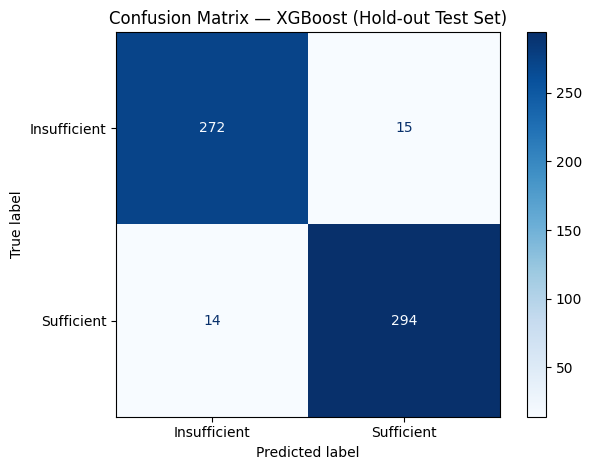

Classification Report (hold-out test set):
              precision    recall  f1-score   support

Insufficient       0.95      0.95      0.95       287
  Sufficient       0.95      0.95      0.95       308

    accuracy                           0.95       595
   macro avg       0.95      0.95      0.95       595
weighted avg       0.95      0.95      0.95       595


MyComPuTeMetRIX — XGBoost (hold-out test):
Confusion Matrix:
[[272  15]
 [ 14 294]]

Metrics:
  Accuracy: 0.9513
  Precision: 0.9513
  Recall: 0.9513
  F1: 0.9513
  MCC: 0.9024

Best CV validation MCC: 0.858
Hold-out test MCC:      0.9024


In [34]:
# Evaluation on hold-out test set — shows generalisation performance
# Adapted from: AI1 Exercise 11 (Prof. Dr. Florian Haselbeck, HSWT, 2026)
if winner_name == 'XGBoost':
    y_test_pred_enc = model_tv.predict(X_test_scaled)
    y_test_pred = le_final.inverse_transform(y_test_pred_enc)
else:
    y_test_pred = model_tv.predict(X_test_scaled)

# Visual confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Insufficient', 'Sufficient'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — ' + winner_name + ' (Hold-out Test Set)')
plt.tight_layout()
plt.show()

# Detailed classification report
print('Classification Report (hold-out test set):')
print(classification_report(y_test, y_test_pred))

# Apply MyComPuTeMetRIX
print('\nMyComPuTeMetRIX — ' + winner_name + ' (hold-out test):')
final_metrics = MyComPuTeMetRIX(y_test, y_test_pred)

print('\nBest CV validation MCC: ' + str(round(winner_score, 4)))
print('Hold-out test MCC:      ' + str(round(final_metrics['MCC'], 4)))

---
## Feature Importance Analysis

Feature importance shows which soil features the model relied on most for its predictions. This is valuable for:
- Understanding which soil properties are most predictive of nutrient status
- Explaining model decisions to agronomists and stakeholders
- Informing future feature selection

**Reference:** Adapted from AI1 Exercise 10 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [35]:
# Feature importance — Random Forest and XGBoost
# Adapted from: AI1 Exercise 10 (Prof. Dr. Florian Haselbeck, HSWT, 2026)

if winner_name == 'Random Forest':
    # extract Feature Importance
    importances = model_final.feature_importances_
    feature_names = final_columns

    # Display the importance of the features
    feature_importance_df = pd.DataFrame(
        {'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(
        by='Importance', ascending=False)

    print(feature_importance_df)

    plt.figure(figsize=(12, 6))
    plt.bar(feature_importance_df['Feature'][:15],
            feature_importance_df['Importance'][:15],
            color='tomato', edgecolor='black', linewidth=0.5)
    plt.xlabel('Feature')
    plt.ylabel('Importance')
    plt.title('Feature Importance — Random Forest (Top 15)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

elif winner_name == 'XGBoost':
    # XGBoost feature importance function (professor's exact pattern)
    def xgb_output_featimps(importance_type):
        # extract feature Importance
        importances = model_final.get_booster().get_score(
            importance_type=importance_type)
        feature_names = final_columns

        # feature name importance mapping
        feature_importances = {}
        for ind in range(len(feature_names)):
            if 'f' + str(ind) not in importances.keys():
                feature_importances[feature_names[ind]] = 0
            else:
                feature_importances[feature_names[ind]] = importances['f' + str(ind)]

        # Display the importance of the features
        feature_importance_df = pd.DataFrame(
            {'Feature': feature_importances.keys(),
             'Importance': feature_importances.values()})
        feature_importance_df = feature_importance_df.sort_values(
            by='Importance', ascending=False)
        print('Output for importance_type: ' + importance_type)
        print(feature_importance_df)
        return feature_importance_df

    xgb_output_featimps('gain')
    print()
    xgb_output_featimps('cover')
    print()
    xgb_output_featimps('weight')

elif winner_name == 'Logistic Regression':
    coef_df = pd.DataFrame({
        'Feature':     final_columns,
        'Coefficient': model_final.coef_[0]
    }).sort_values(by='Coefficient', key=abs, ascending=False)
    print('Logistic Regression Feature Coefficients:')
    print(coef_df)
    plt.figure(figsize=(12, 5))
    plt.bar(coef_df['Feature'][:15], coef_df['Coefficient'][:15], color='seagreen')
    plt.xlabel('Feature')
    plt.ylabel('Coefficient')
    plt.title('Feature Coefficients — Logistic Regression')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance not directly available for ' + winner_name + '.')

Output for importance_type: gain
             Feature  Importance
0                 pH    2.957091
2           Nitrogen    2.544654
6       SoilMoisture    2.460390
10    pH_CEC_product    1.977276
20     CropType_Rape    1.270452
19    CropType_Maize    1.260782
21    CropType_Wheat    1.155346
5                CEC    1.006168
8      FertilizerUse    0.672424
4          Potassium    0.585197
15     SoilType_Sand    0.564578
3         Phosphorus    0.501748
14     SoilType_Loam    0.344740
12       K_CEC_ratio    0.343474
18       Region_West    0.323107
16      Region_North    0.319137
17      Region_South    0.286265
1      OrganicMatter    0.275199
9          N_P_ratio    0.265157
13      OM_N_product    0.256776
7    IrrigationLevel    0.189063
11  Nitrogen_squared    0.000000

Output for importance_type: cover
             Feature  Importance
6       SoilMoisture   27.617014
2           Nitrogen   23.025856
0                 pH   21.567997
21    CropType_Wheat   20.245358
10    pH

---
## Leaderboard Prediction and Submission
*Responsible: Sudish Kumar Yadav*

## Theory: Predicting on Unknown Data

We use the final model (trained on all 3,000 known samples) to predict on the leaderboard data.

**Critical rules (from assignment instructions):**
- Remove `id` column BEFORE prediction — it is only used to create the submission CSV
- Apply **SAME preprocessing** (tools already fitted on all known data) — only `.transform()`, NEVER `.fit_transform()` on leaderboard data
- Align columns with `.reindex()` — leaderboard may have different category distributions
- Encode predictions: `{'Insufficient': 0, 'Sufficient': 1}` as required by leaderboard

**Reference:** AI1 Group Project specification (Prof. Dr. Florian Haselbeck, HSWT, 2026)

In [36]:
# Assumption: You have loaded the leaderboard data into a DataFrame named 'unknown_data'
# Adapted from: AI1 Group Project specification (Prof. Dr. Florian Haselbeck, HSWT, 2026)
unknown_data = pd.read_csv('SoilNutrientStatus_leaderboard_features.csv')

# Remove the id column — only needed for CSV, not for prediction
X_unknown = unknown_data.drop(columns=['id'])

print('Leaderboard data loaded!')
print('Shape: ' + str(X_unknown.shape))

Leaderboard data loaded!
Shape: (300, 12)


In [37]:
# Apply SAME preprocessing as final model training — transform only, never refit
X_unk_imp = X_unknown.copy()
X_unk_imp[num_cols] = imputer_num_final.transform(X_unknown[num_cols])
X_unk_imp[cat_cols] = imputer_cat_final.transform(X_unknown[cat_cols])

# Same feature engineering
X_unk_fe = add_engineered_features(X_unk_imp)

# Same encoding
X_unk_cod = pd.get_dummies(
    X_unk_fe, columns=['SoilType', 'Region', 'CropType'], drop_first=True)
X_unk_cod['IrrigationLevel'] = X_unk_fe['IrrigationLevel'].map(
    {'Low': 0, 'Medium': 1, 'High': 2})
X_unk_cod['FertilizerUse'] = X_unk_fe['FertilizerUse'].map(
    {'None': 0, 'Moderate': 1, 'Intensive': 2})

# Column alignment — CRITICAL: ensures same columns as training
X_unk_cod = X_unk_cod.reindex(columns=final_columns, fill_value=0)

# Same scaler — transform only
X_unk_scaled = scaler_final.transform(X_unk_cod)

print('Leaderboard preprocessing complete!')
print('Shape: ' + str(X_unk_scaled.shape))

Leaderboard preprocessing complete!
Shape: (300, 22)


In [38]:
# Predict using final model trained on all known samples
if winner_name == 'XGBoost':
    y_test_pred_enc = model_final.predict(X_unk_scaled)
    y_test_pred = le_final.inverse_transform(y_test_pred_enc)
else:
    y_test_pred = model_final.predict(X_unk_scaled)

print('Prediction distribution:')
unique, counts = np.unique(y_test_pred, return_counts=True)
for label, count in zip(unique, counts):
    print('  ' + str(label) + ': ' + str(count) +
          ' (' + str(round(count/len(y_test_pred)*100, 1)) + '%)')

# Initialisation of an empty DataFrame
# Adapted from: AI1 Group Project specification (Prof. Dr. Florian Haselbeck, HSWT, 2026)
final_predictions = pd.DataFrame()

# Transferring the ID column
final_predictions['id'] = unknown_data['id']

# Assumption: 'y_test_pred' contains the predictions
final_predictions['predictions'] = y_test_pred

# Encode the predictions if necessary (check beforehand)
final_predictions['predictions'] = final_predictions['predictions'].map(
    {'Insufficient': 0, 'Sufficient': 1})

# Export the final DataFrame to a CSV file
# The index=False option ensures that the row indices are not saved
final_predictions.to_csv('ready_to_upload.csv', index=False)

print('\nSubmission file created: ready_to_upload.csv')
print('\nFirst 10 predictions:')
print(final_predictions.head(10))

Prediction distribution:
  Insufficient: 139 (46.3%)
  Sufficient: 161 (53.7%)

Submission file created: ready_to_upload.csv

First 10 predictions:
         id  predictions
0  lead_001            0
1  lead_002            0
2  lead_003            0
3  lead_004            1
4  lead_005            0
5  lead_006            1
6  lead_007            1
7  lead_008            1
8  lead_009            0
9  lead_010            0


---
# Summary and Conclusions

## Complete ML Workflow Summary

This notebook presented the complete machine learning workflow for **SoilNutrientStatus binary classification** (ExamGroup9):

| Step | What was done | Key decision |
|---|---|---|
| Data Exploration | Visualisations, statistics, missing value analysis | FertilizerUse: 35% missing — keep and impute |
| Data Split | 80% train+val with 5-fold StratifiedKFold, 20% test | Split BEFORE preprocessing — no leakage |
| Pre-processing | Mean imputation, ordinal/one-hot encoding, StandardScaler | Done inside CV loop — folds independent |
| Feature Engineering | 5 domain-informed new features | After imputation — pure arithmetic, no leakage |
| Model Training | KNN, Logistic Regression, SVM, Random Forest, XGBoost | All models from course, all same CV folds |
| Model Comparison | MCC compared across all models | Same cv object for all — fair comparison |
| Final Model | Trained on all 3,000 known samples | Leaderboard = external test, use all data |
| Leaderboard | `ready_to_upload.csv` with Insufficient=0, Sufficient=1 | Same preprocessing applied — transform only |

## Key Decisions and Justifications

- **StratifiedKFold over simple split** → more stable, each sample used for validation exactly once
- **Preprocessing inside CV loop** → prevents information leakage between folds
- **Feature engineering** → captures non-linear soil chemistry interactions
- **MCC as primary metric** → uses all four confusion matrix values, the leaderboard ranking metric
- **Train on all 3,000 samples** → more data → better leaderboard performance
- **Random Search for large grids** (RF, XGBoost) → more efficient than Grid Search
- **Grid Search for small grids** (KNN, LogReg, SVM linear) → exhaustive but feasible

---

## References

### Course Materials
All code structures adapted from: **AI1 Exercise Notebooks** (Prof. Dr. Florian Haselbeck, HSWT, 2026)
- Exercise 3: Data Exploration
- Exercise 4: Data Pre-processing and Data Splits
- Exercise 5: Feature Engineering and Dimensionality Reduction
- Exercise 6: KNN Classification with Train-Val-Test and Random Search
- Exercise 7: KNN with Cross-Validation
- Exercise 8: Logistic Regression
- Exercise 9: Support Vector Machine
- Exercise 10: Random Forest and XGBoost
- Exercise 11: Comparison of Multiple Models

### Libraries
- scikit-learn: https://scikit-learn.org/stable/
- XGBoost: https://xgboost.readthedocs.io/
- pandas: https://pandas.pydata.org/docs/
- numpy: https://numpy.org/doc/
- matplotlib: https://matplotlib.org/stable/
- seaborn: https://seaborn.pydata.org/

### Dataset
SoilNutrientStatus dataset provided by Prof. Dr. Florian Haselbeck, Hochschule Weihenstephan-Triesdorf, AI1 Group Project 2026.